# ClearBank – Análise Financeira de Transações

**Analista:** Desenvolvedor Junior  
**Empresa:** ClearBank Fintech  
**Python:** 3.10+

## Como executar

1. Certifique-se de que o arquivo `transacoes.csv` está na **mesma pasta** que este notebook.
2. Execute as células **em ordem** de cima para baixo (Kernel → Restart & Run All).
3. A célula de execução principal chamará todas as funções e gerará:
   - Relatório formatado no terminal (saída da célula)
   - Arquivo `relatorio.json` na mesma pasta
   - Arquivo `grafico.png` com o gráfico mensal

## Estrutura do `transacoes.csv`

| Coluna | Tipo | Descrição |
|--------|------|-----------|
| id | inteiro | Identificador único da transação |
| data | texto | Data no formato AAAA-MM-DD |
| cliente_id | texto | Código do cliente (não pode ser vazio) |
| tipo | texto | `credito` ou `debito` |
| valor | decimal | Valor da transação (deve ser maior que 0) |
| descricao | texto | Descrição livre da operação |
| categoria | texto | Ex.: salario, compra, transferencia |

In [4]:
import csv
import json
from datetime import datetime

# ── Constants ────────────────────────────────────────────────────────────────
MAX_VALUE: float = 10_000.00
CSV_FILE: str = "transacoes.csv"
JSON_FILE: str = "relatorio.json"
CHART_FILE: str = "grafico.png"
VALID_TYPES: set[str] = {"credito", "debito"}

print("Constants loaded:")
print(f"  MAX_VALUE = R$ {MAX_VALUE:,.2f}")
print(f"  CSV_FILE     = {CSV_FILE}")
print(f"  JSON_FILE    = {JSON_FILE}")

Constants loaded:
  MAX_VALUE = R$ 10,000.00
  CSV_FILE     = transacoes.csv
  JSON_FILE    = relatorio.json


In [5]:
def read_transactions(filepath: str) -> list[dict]:
    """Read the CSV file and return the raw transaction list as dictionaries."""
    try:
        with open(filepath, encoding="utf-8", newline="") as file:
            file_reader = csv.DictReader(file)
            return list(file_reader)
    except FileNotFoundError:
        print(f"ERROR: file '{filepath}' not found.")
        print("Create the transacoes.csv file before executing this notebook")
        return []


# ── Quick validation test──────────────────────────────────────────────────────────────
raw_transactions = read_transactions(CSV_FILE)
print(f"Rows read from CSV: {len(raw_transactions)}")
print("First row:", raw_transactions[0] if raw_transactions else "empty")

Rows read from CSV: 30
First row: {'id': '1', 'data': '2026-01-05', 'cliente_id': 'CLI001', 'tipo': 'credito', 'valor': '3500.00', 'descricao': 'Salário janeiro', 'categoria': 'salario'}


In [6]:
def validate_transaction_row(row: dict) -> dict | None:
    """
    Validate and convert a raw row from CSV.
    Return a dict with the correct types if valid or None if invalid
    """
    try:
        id_val = int(row.get("id", "").strip())
    except (ValueError, AttributeError):
        return None

    client_id = row.get("cliente_id", "").strip()
    if not client_id:
        return None

    try:
        date = datetime.strptime(row.get("data", "").strip(), "%Y-%m-%d")
    except (ValueError, AttributeError):
        return None

    type = row.get("tipo", "").strip().lower()
    if type not in VALID_TYPES:
        return None

    try:
        value = float(row.get("valor", "").strip())
        if value <= 0:
            return None
    except (ValueError, AttributeError):
        return None

    return {
        "id": id_val,
        "data": date,
        "cliente_id": client_id,
        "tipo": type,
        "valor": value,
        "descricao": row.get("descricao", "").strip(),
        "categoria": row.get("categoria", "").strip(),
    }


# ── Quick validation test ──────────────────────────────────────────────────────────────
valid_row = {"id": "1", "data": "2026-01-05", "cliente_id": "CLI001",
                "tipo": "credito", "valor": "3500.00", "descricao": "Salário", "categoria": "salario"}
invalid_row = {"id": "abc", "data": "2026-01-05", "cliente_id": "CLI001",
                  "tipo": "credito", "valor": "100.00", "descricao": "Teste", "categoria": "compra"}

valid_result = validate_transaction_row(valid_row)
invalid_result = validate_transaction_row(invalid_row)

print("Valid row   →", valid_result)
print("Invalid row →", invalid_result)

Valid row   → {'id': 1, 'data': datetime.datetime(2026, 1, 5, 0, 0), 'cliente_id': 'CLI001', 'tipo': 'credito', 'valor': 3500.0, 'descricao': 'Salário', 'categoria': 'salario'}
Invalid row → None


In [7]:
def process_transactions(raw_transactions: list[dict]) -> tuple[list[dict], int]:
    """
    Iterate over the transactions, validate each one and return
    a list of valid transactions and the count of invalid ones.
    """
    valid_transactions: list[dict] = []
    total = len(raw_transactions)

    for row in raw_transactions:
        transaction = validate_transaction_row(row)
        if transaction is not None:
            valid_transactions.append(transaction)

    invalid_transactions = total - len(valid_transactions)

    print("\n===== RESUMO DA LIMPEZA =====")
    print(f"Total de linhas lidas: {total}")
    print(f"Linhas válidas:        {len(valid_transactions)}")
    print(f"Linhas inválidas:      {invalid_transactions}")

    return valid_transactions, invalid_transactions


# ── Quick validation test ──────────────────────────────────────────────────────────────
valid_transactions, count_invalid = process_transactions(raw_transactions)
print(f"\nTransactions ready for analysis: {len(valid_transactions)}")


===== RESUMO DA LIMPEZA =====
Total de linhas lidas: 30
Linhas válidas:        23
Linhas inválidas:      7

Transactions ready for analysis: 23


In [8]:
def calculate_date_range(transactions: list[dict]) -> tuple[datetime, datetime, int]:
    """
    Return the data in ascending order, from the oldest to newest and the days
    between them from a list of valid transactions
    """
    dates = [transaction["data"] for transaction in transactions]
    oldest_date = min(dates)
    newest_date = max(dates)
    date_range = (newest_date - oldest_date).days
    return oldest_date, newest_date, date_range


def build_report(transactions: list[dict], count_invalid: int) -> dict:
    """
    Group transactions by month and calculate it's financial metrics.
    Identify suspects transactions (valor > MAX_VALUE)
    Return a compatible structure with the output JSON
    """
    mensal_summary: dict[str, dict] = {}
    suspect_transactions: list[dict] = []

    for transaction in transactions:
        month = transaction["data"].strftime("%Y-%m")

        if month not in mensal_summary:
            mensal_summary[month] = {
                "quantidade": 0,
                "total_credito": 0.0,
                "total_debito": 0.0,
                "saldo": 0.0,
                "media": 0.0,
                "maior_valor": 0.0,
                "menor_valor": float("inf"),
                "_soma_valores": 0.0,
            }

        actual_month = mensal_summary[month]
        actual_month["quantidade"] += 1
        actual_month["_soma_valores"] += transaction["valor"]

        if transaction["tipo"] == "credito":
            actual_month["total_credito"] += transaction["valor"]
        else:
            actual_month["total_debito"] += transaction["valor"]

        if transaction["valor"] > actual_month["maior_valor"]:
            actual_month["maior_valor"] = transaction["valor"]
        if transaction["valor"] < actual_month["menor_valor"]:
            actual_month["menor_valor"] = transaction["valor"]

        if transaction["valor"] > MAX_VALUE:
            suspect_transactions.append({
                "id": transaction["id"],
                "cliente_id": transaction["cliente_id"],
                "data": transaction["data"].strftime("%Y-%m-%d"),
                "valor": transaction["valor"],
            })

    for month_date, month in mensal_summary.items():
        month["saldo"] = round(month["total_credito"] - month["total_debito"], 2)
        month["media"] = round(month["_soma_valores"] / month["quantidade"], 2)
        month["total_credito"] = round(month["total_credito"], 2)
        month["total_debito"] = round(month["total_debito"], 2)
        month["maior_valor"] = round(month["maior_valor"], 2)
        month["menor_valor"] = round(month["menor_valor"], 2)
        del month["_soma_valores"]

    oldest_date, newest_date, dias = calculate_date_range(transactions)

    return {
        "gerado_em": datetime.today().strftime("%Y-%m-%d"),
        "total_transacoes_validas": len(transactions),
        "total_transacoes_invalidas": count_invalid,
        "periodo": {
            "inicio": oldest_date.strftime("%Y-%m-%d"),
            "fim": newest_date.strftime("%Y-%m-%d"),
            "dias": dias,
        },
        "resumo_mensal": dict(sorted(mensal_summary.items())),
        "transacoes_suspeitas": suspect_transactions,
    }


# ── Quick validation test ──────────────────────────────────────────────────────────────
report = build_report(valid_transactions, count_invalid)
print("Month found:", list(report["resumo_mensal"].keys()))
print("Suspect transactions:", len(report["transacoes_suspeitas"]))
print("Range:", report["periodo"])

Month found: ['2026-01', '2026-02', '2026-03', '2026-04']
Suspect transactions: 3
Range: {'inicio': '2026-01-05', 'fim': '2026-04-30', 'dias': 115}


In [9]:
def currency_format(value: float) -> str:
    """Format a float to brazil real: R$ 1.840,25"""
    return f"R$ {value:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")


def print_report(report: dict) -> None:
    """Print the mensal formatted report on terminal"""
    range = report["periodo"]

    print("\n" + "=" * 50)
    print("       RELATÓRIO FINANCEIRO – CLEARBANK")
    print("=" * 50)
    print(f"Gerado em:              {report['gerado_em']}")
    print(f"Período analisado:      {range['inicio']} → {range['fim']}")
    print(f"Dias no período:        {range['dias']}")
    print(f"Transações válidas:     {report['total_transacoes_validas']}")
    print(f"Transações inválidas:   {report['total_transacoes_invalidas']}")

    print("\n===== RELATÓRIO MENSAL =====")
    for mes, dados in report["resumo_mensal"].items():
        print(f"\nMês: {mes}")
        print(f"  Transações:    {dados['quantidade']}")
        print(f"  Total crédito: {currency_format(dados['total_credito'])}")
        print(f"  Total débito:  {currency_format(dados['total_debito'])}")
        print(f"  Saldo:         {currency_format(dados['saldo'])}")
        print(f"  Média:         {currency_format(dados['media'])}")
        print(f"  Maior valor:   {currency_format(dados['maior_valor'])}")
        print(f"  Menor valor:   {currency_format(dados['menor_valor'])}")

    print("\n===== TRANSAÇÕES SUSPEITAS =====")
    suspects = report["transacoes_suspeitas"]
    if suspects:
        for s in suspects:
            print(f"ID: {s['id']} | Cliente: {s['cliente_id']} | Data: {s['data']} | Valor: {currency_format(s['valor'])}")
    else:
        print("Nenhuma transação suspeita encontrada.")

    print("\n" + "=" * 50)


# ── Quick validation test ──────────────────────────────────────────────────────────────
print("Test formatting:", currency_format(1840.25))
print("Test formatting:", currency_format(15000.00))

Test formatting: R$ 1.840,25
Test formatting: R$ 15.000,00


In [10]:
def export_report(report: dict, filepath: str) -> None:
    """Save report in JSON format on the defined path"""
    try:
        with open(filepath, "w", encoding="utf-8") as file:
            json.dump(report, file, ensure_ascii=False, indent=2)
        print(f"JSON report saved on: {filepath}")
    except OSError as e:
        print(f"ERROR on saving JSON: {e}")


# ── Quick validation test ──────────────────────────────────────────────────────────────
import os
export_report(report, JSON_FILE)
if os.path.exists(JSON_FILE):
    size = os.path.getsize(JSON_FILE)
    print(f"File created with {size} bytes.")

JSON report saved on: relatorio.json
File created with 1422 bytes.


In [11]:
# ── PRINCIPAL EXECUTION CELL ─────────────────────────────────────────────
# Execute this cell to run the entire pipeline

print("Starting ClearBank financial analysis...")
print(f"Reading file: {CSV_FILE}\n")

# 1. Read file
raw_rows = read_transactions(CSV_FILE)

if raw_rows:
    # 2. Validation and data cleaning
    valid_transactions, count_invalid = process_transactions(raw_rows)

    if valid_transactions:
        # 3. Building report
        report = build_report(valid_transactions, count_invalid)

        # 4. Print report on terminal
        print_report(report)

        # 5. Export JSON
        export_report(report, JSON_FILE)
    else:
        print("WARNING: No valid transaction found, review the csv file")
else:
    print("WARNING: no valid row, review if the CSV file exists or if the data are correct")

Starting ClearBank financial analysis...
Reading file: transacoes.csv


===== RESUMO DA LIMPEZA =====
Total de linhas lidas: 30
Linhas válidas:        23
Linhas inválidas:      7

       RELATÓRIO FINANCEIRO – CLEARBANK
Gerado em:              2026-06-10
Período analisado:      2026-01-05 → 2026-04-30
Dias no período:        115
Transações válidas:     23
Transações inválidas:   7

===== RELATÓRIO MENSAL =====

Mês: 2026-01
  Transações:    5
  Total crédito: R$ 16.000,00
  Total débito:  R$ 720,40
  Saldo:         R$ 15.279,60
  Média:         R$ 3.344,08
  Maior valor:   R$ 12.500,00
  Menor valor:   R$ 89,90

Mês: 2026-02
  Transações:    6
  Total crédito: R$ 18.500,00
  Total débito:  R$ 1.775,90
  Saldo:         R$ 16.724,10
  Média:         R$ 3.379,32
  Maior valor:   R$ 15.000,00
  Menor valor:   R$ 55,90

Mês: 2026-03
  Transações:    7
  Total crédito: R$ 8.200,00
  Total débito:  R$ 3.328,90
  Saldo:         R$ 4.871,10
  Média:         R$ 1.646,99
  Maior valor:   R$ 4.200

---
## Chart with matplotlib

Stacked bar chart with credit and debit per month

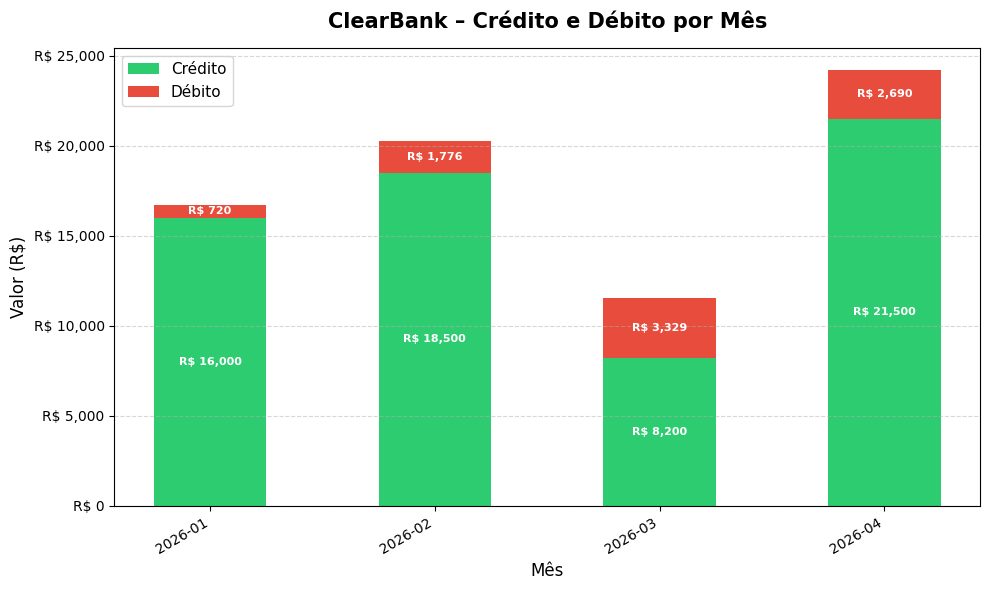

Chart saved on: grafico.png


In [13]:
import matplotlib.pyplot as matplot

def generate_chart(report: dict, filepath: str) -> None:
    """Generate stacked bar chart (credit and debit per month) and saves as image"""
    months = list(report["resumo_mensal"].keys())
    credits = [report["resumo_mensal"][month]["total_credito"] for month in months]
    debits = [report["resumo_mensal"][month]["total_debito"] for month in months]

    x = range(len(months))
    width = 0.5

    # Create a chart with 10 inches wide and 6 inches tall
    # axes is the individual plot to draw the chart
    figure, chart_axes = matplot.subplots(figsize=(10, 6))

    credit_bars = chart_axes.bar(x, credits, width, label="Crédito", color="#2ecc71")
    debit_bars = chart_axes.bar(x, debits, width, bottom=credits, label="Débito", color="#e74c3c")

    chart_axes.set_title("ClearBank – Crédito e Débito por Mês", fontsize=15, fontweight="bold", pad=15)
    chart_axes.set_xlabel("Mês", fontsize=12)
    chart_axes.set_ylabel("Valor (R$)", fontsize=12)
    chart_axes.set_xticks(list(x))
    chart_axes.set_xticklabels(months, rotation=30, ha="right")
    chart_axes.legend(fontsize=11)
    chart_axes.yaxis.set_major_formatter(matplot.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))
    chart_axes.grid(axis="y", linestyle="--", alpha=0.5)

    # Credit bars label
    for bar, val in zip(credit_bars, credits):
        if val > 0:
            chart_axes.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2,
                    f"R$ {val:,.0f}", ha="center", va="center", fontsize=8, color="white", fontweight="bold")

    # Debit bars label
    for bar, base, val in zip(debit_bars, credits, debits):
        if val > 0:
            chart_axes.text(bar.get_x() + bar.get_width() / 2, base + val / 2,
                    f"R$ {val:,.0f}", ha="center", va="center", fontsize=8, color="white", fontweight="bold")

    matplot.tight_layout()
    matplot.savefig(filepath, dpi=150)
    matplot.show()
    print(f"Chart saved on: {filepath}")

generate_chart(report, CHART_FILE)

---
## Analysis com pandas

The alternative analysis using pandas is implemented on the file `analise_pandas.py`.
Execute with `python analise_pandas.py`

The results will be compared with the native solution from this file